# LC


# コード
## Utility: 
###  - LCファイル名一覧の取得

In [29]:
import os

def get_lc_files(dir_path_lc= "./data_LC/14d"): 
    filenames= [
        f for f in os.listdir(dir_path_lc) if os.path.isfile(os.path.join(dir_path_lc, f))
    ]
    # print(filenames)
    return filenames

In [30]:
get_lc_files()

['4fgl_j1427.9-4206_lightcurve.fits',
 '4fgl_j1512.8-0906_lightcurve.fits',
 '4fgl_j0957.6+5523_lightcurve.fits',
 '4fgl_j0428.6-3756_lightcurve.fits',
 '4fgl_j2253.9+1609_lightcurve.fits',
 '4fgl_j2232.6+1143_lightcurve.fits',
 '4fgl_j0457.0-2324_lightcurve.fits',
 '4fgl_j1159.5+2914_lightcurve.fits',
 '4fgl_j0721.9+7120_lightcurve.fits',
 '4fgl_j1504.4+1029_lightcurve.fits',
 '4fgl_j2202.7+4216_lightcurve.fits',
 '4fgl_j1104.4+3812_lightcurve.fits',
 '4fgl_j1224.9+2122_lightcurve.fits',
 '4fgl_j0112.1+2245_lightcurve.fits',
 '4fgl_j1256.1-0547_lightcurve.fits',
 '4fgl_j2158.8-3013_lightcurve.fits',
 '4fgl_j0538.8-4405_lightcurve.fits']

### - 天体名対応辞書作成

In [7]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 50
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  
  
  sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_cls_converted = str(sources_blazars_cls).strip()

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


In [13]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:15]
# dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_j0112.1+2245']# dict_sourcename[(dict_sourcename['4FGL name'] == '4fgl_j0112.1+2245')]

4FGL name,assoc name,CLASS,index
str18,str28,str5,int64
4fgl_j2253.9+1609,3c_454.3,FSRQ,1
4fgl_j1104.4+3812,mkn_421,BLL,2
4fgl_j2202.7+4216,bl_lac,BLL,3
4fgl_j2232.6+1143,cta_102,FSRQ,4
4fgl_j1256.1-0547,3c_279,FSRQ,5
4fgl_j0721.9+7120,s5_0716+71,BLL,6
4fgl_j1427.9-4206,pks_1424-41,FSRQ,7
4fgl_j0428.6-3756,pks_0426-380,bll,8
4fgl_j0538.8-4405,pks_0537-441,BLL,9


# LCの描画
## 全LCの描画

4fgl_j1427.9-4206:pks_1424-41 7
4fgl_j1512.8-0906:pks_1510-089 12
4fgl_j0957.6+5523:4c_+55.17 17
4fgl_j0428.6-3756:pks_0426-380 8
4fgl_j2253.9+1609:3c_454.3 1
4fgl_j2232.6+1143:cta_102 4
4fgl_j0457.0-2324:pks_0454-234 11
4fgl_j1159.5+2914:ton_599 14
4fgl_j0721.9+7120:s5_0716+71 6
4fgl_j1504.4+1029:pks_1502+106 13
4fgl_j2202.7+4216:bl_lac 3
4fgl_j1104.4+3812:mkn_421 2
4fgl_j1224.9+2122:4c_+21.35 18
4fgl_j0112.1+2245:s2_0109+22 34
4fgl_j1256.1-0547:3c_279 5
4fgl_j2158.8-3013:pks_2155-304 10
4fgl_j0538.8-4405:pks_0537-441 9


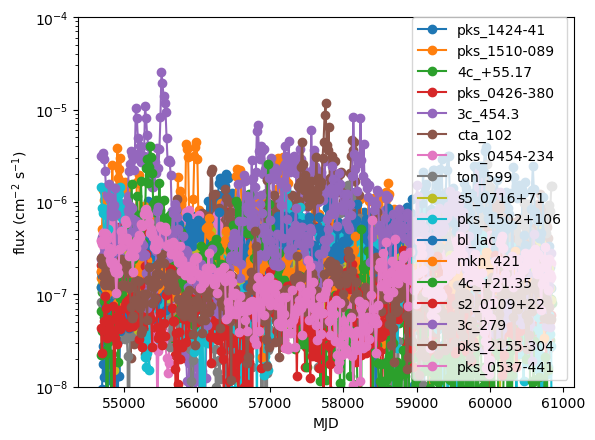

<Figure size 640x480 with 0 Axes>

In [11]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

for file in file_list:
    if file.endswith('.fits'):
        lc_tab = Table.read(os.path.join(lc_file_dir, file))
        # Add a new column with the average of tmax_mjd and tmin_mjd
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        # # Save the modified table back to a new fits file
        # lc_tab.write(os.path.join(lc_file_dir, f'modified_{file}'), overwrite=True)
        # fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
        sourcename_4fgl = file.split('_')[1] # Extract the 4FGL name from the filename
        sourceinfo = dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_' + sourcename_4fgl]
        sourcename_assoc = sourceinfo['assoc name'].data[0]
        sourceindex = sourceinfo['index'].data[0]
        print('4fgl_' + sourcename_4fgl + ':' + str(sourcename_assoc) + ' ' + str(sourceindex))
        # print(sourcename_assoc)
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']
        plt.plot(lc_x,lc_y ,marker='o',label=sourcename_assoc)

# lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
# plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
plt.legend()
plt.show()
plt.tight_layout()


## 選択的に描画（明るさ順指定可能）

    4FGL name     assoc name CLASS index
----------------- ---------- ----- -----
4fgl_j2253.9+1609   3c_454.3  FSRQ     1
    4FGL name      assoc name  CLASS index
----------------- ------------ ----- -----
4fgl_j1512.8-0906 pks_1510-089  FSRQ    12
    4FGL name      assoc name  CLASS index
----------------- ------------ ----- -----
4fgl_j1504.4+1029 pks_1502+106  FSRQ    13
    4FGL name     assoc name CLASS index
----------------- ---------- ----- -----
4fgl_j1159.5+2914    ton_599  fsrq    14


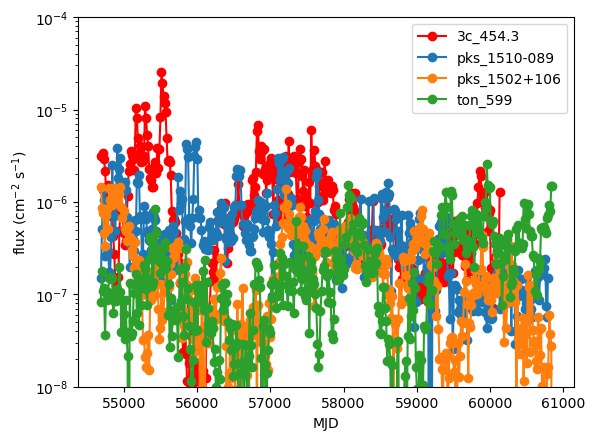

<Figure size 640x480 with 0 Axes>

In [62]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

plot_refsource = True
if plot_refsource:
 # Plot the light curve of the reference source
  dict_sourcename = get_dict_sourcenames()
  # print(dict_sourcename)
  # print(dict_sourcename[0])
  # print(dict_sourcename[0]['4FGL name'])
  # print(dict_sourcename[0]['assoc name'])
  # print(dict_sourcename[0]['index'])
  source = dict_sourcename[0]
  print(source)
  lc_tab = Table.read(os.path.join(lc_file_dir, source['4FGL name'] + '_lightcurve.fits'))
  lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
  lc_x=lc_tab['t_mjd']
  lc_y=lc_tab['flux']
  plt.plot(lc_x,lc_y ,marker='o',color= 'red', label=source['assoc name'])



for source in dict_sourcename[11:14]:
  print(source)
  lc_tab = Table.read(os.path.join(lc_file_dir, source['4FGL name'] + '_lightcurve.fits'))
  lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
  lc_x=lc_tab['t_mjd']
  lc_y=lc_tab['flux']
  plt.plot(lc_x,lc_y ,marker='o',label=source['assoc name'])

plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
# plt.xlim(57790-14*20-5, 57790+14*20+5)  # Adjust the x-axis limits to show a 14-day window around MJD 57790
plt.legend()
plt.show()
plt.tight_layout()

# 1d SED描画可能性検証



In [64]:
lc_file_dir = 'data_LC/1d'
file_list = get_lc_files(lc_file_dir) 
print(file_list)
dict_source = get_dict_sourcenames()
dict_source[dict_sourcename['assoc name'] == '3c_454.3']



['4fgl_j2253.9+1609_lightcurve2.fits', '4fgl_j2253.9+1609_lightcurve1.fits']


4FGL name,assoc name,CLASS,index
str18,str28,str5,int64
4fgl_j2253.9+1609,3c_454.3,FSRQ,1


### - 1d LC ファイル読込
### - SED ecsv ファイル読込
### - 存否検索・列追加
### - 1d LC の描画

4fgl_j2253.9+1609
ValidSED       t_mjd       ...  dnde10000_index   dnde10000_index_fixed
                 d         ...                                         
-------- ----------------- ... ------------------ ---------------------
    True 54683.15603222222 ...  3.209068303340056    3.2362193866213347
    True 54684.15603222222 ... 3.2008150051956807     3.236219386632437
    True 54685.15603222222 ... 3.1294730179669323    3.2362193866102333
    True 54686.15603222222 ...  3.245905895490642    3.2362193866213347
    True 54687.15603222222 ...   3.23989445263983    3.2362193866213347
    True 54688.15603222222 ... 3.3431700739169705    3.2362193866213347
    True 54689.15603222222 ...   3.14184881766902    3.2362193866213347
    True 54690.15603222222 ...  3.218983860729556     3.236219386632437
    True 54691.15603222222 ... 3.2040426090176988     3.236219386632437
    True 54692.15603222222 ... 3.2447908130345082    3.2362193866213347
     ...               ... ...                

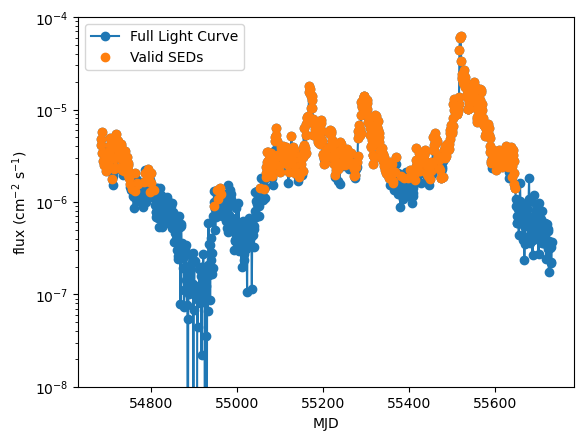

         flux         
----------------------
4.8288037472370375e-06
 4.143614469141857e-06
 5.712892406171136e-06
 3.403919051537105e-06
 3.450323080075226e-06
 2.784841386483086e-06
2.7394621844031375e-06
2.8057972669830935e-06
2.4836105663826385e-06
2.5585730134503668e-06
        flux       
-------------------
 -5.316160444884181
-5.3826206590816605
 -5.243143955152855
 -5.468020776404361
 -5.462140236716743
 -5.555199535476544
 -5.562334690198572
 -5.551943712142777
-5.6049165011404725
-5.5920021851463675


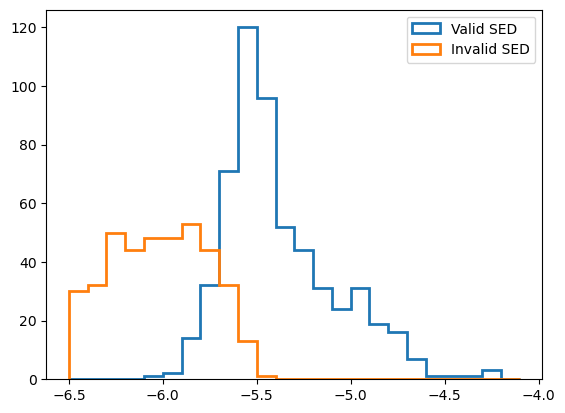

In [134]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os
lc_file_dir = 'data_LC/1d'
source = dict_source[dict_source['assoc name'] == '3c_454.3']
print(source['4FGL name'].data[0])

###########################
### Read the data       ###
###########################
# LC
lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve1.fits')
# lc_filepath  = os.path.join(lc_file_dir, source['4FGL name'].data[0] +'_lightcurve2.fits')
lc_tab = Table.read(lc_filepath)

# SED
sed_filepath = 'data/3C454.3_allsed_1d_min11.ecsv'
# sed_filepath = 'data/3C454.3_allsed_1d_2_min11.ecsv'
sed_tab_0 = Table.read(sed_filepath)
nonzero_mask = (sed_tab_0['e2dnde'] > sed_tab_0['e2dnde_err'])
sed_tab = sed_tab_0[nonzero_mask]

lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
# plt.plot(lc_x,lc_y ,marker='o',color= 'blue', label=source['assoc name'])



###########################
###    データ整形         ###
###########################
obsdates_sed=np.round(np.unique(sed_tab['tstart'].data).tolist(),3)
obsdates_lc=np.round(lc_tab['tmin_mjd'],3)
array_validseds = []
for idx, obsdate_lc in enumerate(obsdates_lc):
  # print(idx, ': obsdate',obsdate_lc)
  mask = (obsdates_sed==obsdate_lc)
  if mask.sum() > 0:
    # print('obsdate', obsdate_lc, '---', mask.sum() )
    # print(lc_tab[idx])
    array_validseds.append(True)
  else:
    # print('obsdate', obsdate_lc)
    array_validseds.append(False)
from astropy.table import Column
lc_tab.add_column(array_validseds, name='ValidSED', index=0)
print(lc_tab)



###########################
###    描画              ###
###########################
### Light Curve ###
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
plt.plot(lc_x,lc_y ,marker='o',label="Full Light Curve")

mask = (lc_tab['ValidSED'] == True)
lc_x=lc_tab[mask]['t_mjd']
lc_y=lc_tab[mask]['flux']
plt.plot(lc_x,lc_y ,marker='o', linestyle='', label="Valid SEDs")


plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-8, 1e-4)
# plt.xlim(57790-14*20-5, 57790+14*20+5)  # Adjust the x-axis limits to show a 14-day window around MJD 57790
plt.legend()
plt.show()
plt.tight_layout()

### Histogram of fluxes ###
hist_valid = plt.hist(np.log10(lc_tab[mask]['flux'].data), bins=np.arange(-6.5, -4.0, 0.1),histtype='step', lw=2, label='Valid SED')
hist_valid = plt.hist(np.log10(lc_tab[np.invert(mask)]['flux'].data), bins=np.arange(-6.5, -4.0, 0.1),histtype='step', lw=2, label='Invalid SED')
plt.legend()
print(lc_tab[mask]['flux'][0:10])
print(np.log10(lc_tab[mask]['flux'][0:10]))



In [114]:
print(pow(10,-5.8))
print(pow(10,-5.9))




1.584893192461114e-06
1.2589254117941661e-06


## Threshold 適用

4fgl_j1427.9-4206:pks_1424-41 7
[55333.7 56145.7 56229.7 56285.7 56299.7 56313.7 56327.7 56341.7 56355.7
 56369.7 56383.7 56397.7 56411.7 56425.7 56439.7 56467.7 56481.7 56495.7
 57391.7 57783.7 57811.7 58091.7 58105.7 58119.7 58133.7 58147.7 58189.7
 59771.7 59785.7 59799.7 59813.7 59827.7 59841.7 59855.7 59869.7 59883.7
 59897.7 59911.7 59925.7 59939.7 59953.7 59967.7 60079.7 60093.7 60107.7
 60149.7 60163.7 60219.7 60233.7 60275.7 60289.7 60303.7 60317.7 60331.7
 60345.7 60359.7 60373.7 60387.7 60401.7 60415.7 60429.7 60457.7 60471.7]


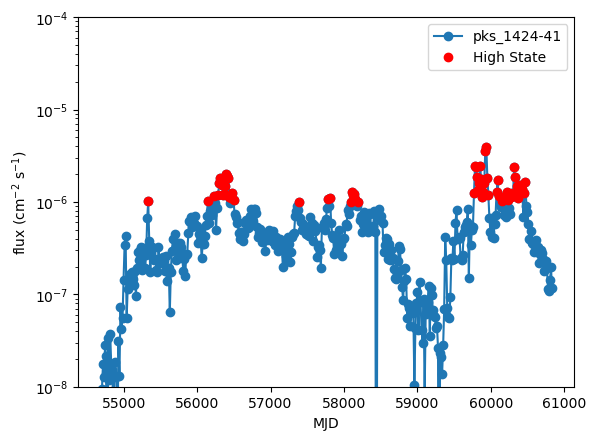

4fgl_j1512.8-0906:pks_1510-089 12
[54717.7 54731.7 54843.7 54857.7 54899.7 54913.7 54927.7 54941.7 54955.7
 54969.7 54983.7 54997.7 55011.7 55025.7 55179.7 55193.7 55207.7 55739.7
 55767.7 55795.7 55851.7 55865.7 55879.7 55949.7 55963.7 55977.7 55991.7
 56005.7 56537.7 56551.7 56565.7 56579.7 56593.7 56831.7 56957.7 57097.7
 57111.7 57125.7 57139.7 57153.7 57167.7 57181.7 57195.7 57209.7 57223.7
 57237.7 57251.7 57279.7 57629.7 57643.7 57657.7 58231.7 58343.7 58413.7
 58511.7 58525.7 58581.7 58595.7 58609.7 58623.7]


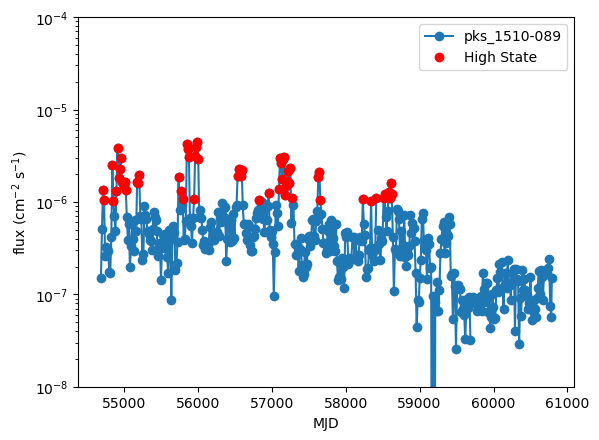

4fgl_j0957.6+5523:4c_+55.17 17
[]


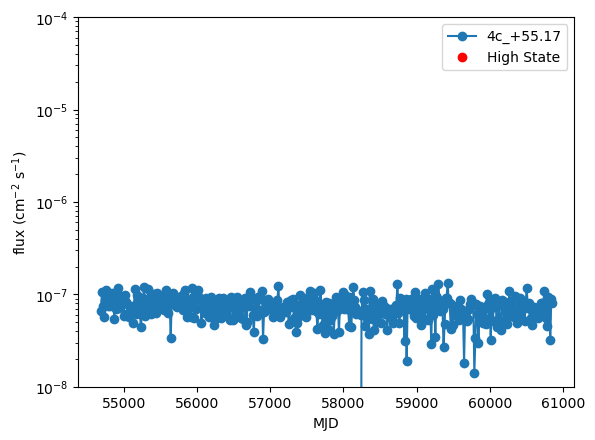

4fgl_j0428.6-3756:pks_0426-380 8
[]


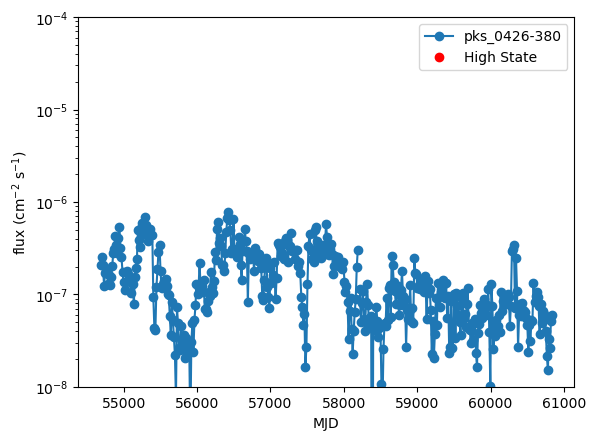

4fgl_j2253.9+1609:3c_454.3 1
[54689.7 54703.7 54717.7 54731.7 54745.7 54759.7 54773.7 54787.7 54801.7
 55053.7 55067.7 55081.7 55095.7 55109.7 55123.7 55137.7 55151.7 55165.7
 55179.7 55193.7 55207.7 55221.7 55235.7 55249.7 55263.7 55277.7 55291.7
 55305.7 55319.7 55333.7 55347.7 55361.7 55375.7 55389.7 55403.7 55417.7
 55431.7 55445.7 55459.7 55473.7 55487.7 55501.7 55515.7 55529.7 55543.7
 55557.7 55571.7 55585.7 55599.7 55613.7 55627.7 55641.7 56565.7 56747.7
 56761.7 56775.7 56789.7 56803.7 56817.7 56831.7 56845.7 56859.7 56873.7
 56887.7 56901.7 56915.7 56929.7 56943.7 56957.7 56971.7 56985.7 56999.7
 57013.7 57027.7 57055.7 57069.7 57083.7 57097.7 57111.7 57153.7 57181.7
 57195.7 57209.7 57237.7 57251.7 57265.7 57279.7 57293.7 57307.7 57321.7
 57335.7 57349.7 57377.7 57391.7 57405.7 57419.7 57433.7 57447.7 57461.7
 57489.7 57531.7 57559.7 57573.7 57587.7 57601.7 57615.7 57629.7 57671.7
 57685.7 57699.7 57713.7 57727.7 57741.7 57755.7 57769.7 57783.7 57797.7
 57811.7 57825.7 57839

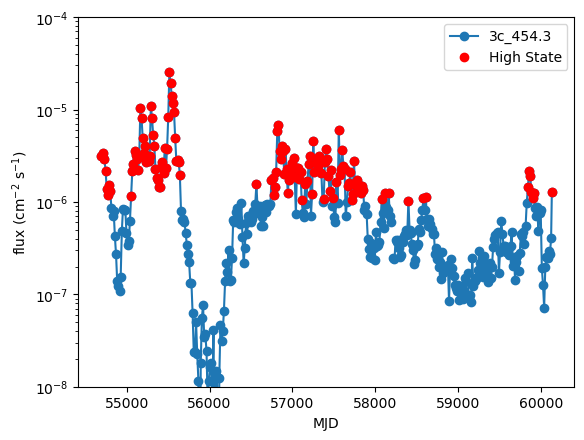

4fgl_j2232.6+1143:cta_102 4
[55725.7 56187.7 56201.7 56215.7 56243.7 56383.7 56397.7 56677.7 56691.7
 56957.7 57055.7 57293.7 57377.7 57391.7 57405.7 57419.7 57433.7 57447.7
 57461.7 57475.7 57489.7 57503.7 57531.7 57545.7 57559.7 57573.7 57587.7
 57615.7 57629.7 57643.7 57657.7 57671.7 57685.7 57699.7 57713.7 57727.7
 57741.7 57755.7 57769.7 57783.7 57797.7 57811.7 57825.7 57839.7 57853.7
 57867.7 57881.7 57895.7 57909.7 57923.7 57937.7 57951.7 57965.7 57979.7
 57993.7 58021.7 58035.7 58049.7 58077.7 58091.7 58105.7 58119.7 58133.7
 58147.7 58161.7 58217.7 59953.7 59981.7 60023.7 60681.7]


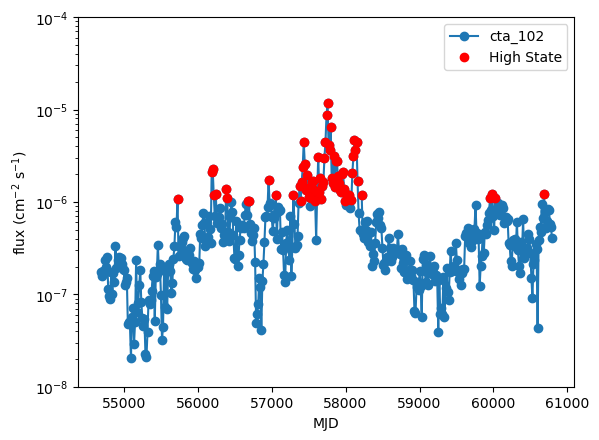

4fgl_j0457.0-2324:pks_0454-234 11
[]


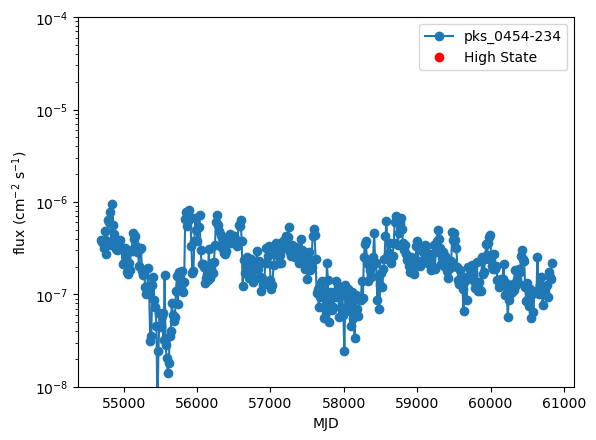

4fgl_j1159.5+2914:ton_599 14
[58063.7 58077.7 58091.7 58105.7 59393.7 59463.7 59477.7 59925.7 59953.7
 59967.7 59981.7 59995.7 60835.7 60842.9]


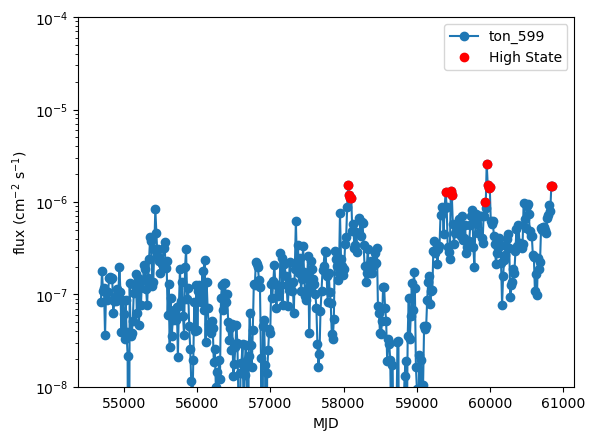

4fgl_j0721.9+7120:s5_0716+71 6
[]


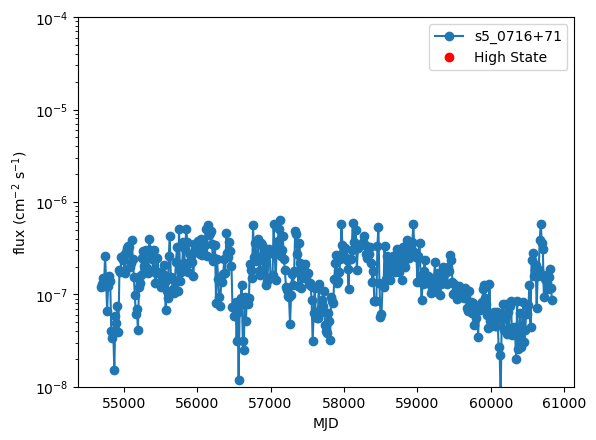

4fgl_j1504.4+1029:pks_1502+106 13
[54689.7 54801.7 54815.7 54829.7 54857.7 54871.7 54885.7 54899.7 54913.7
 54927.7 54941.7 54955.7 57209.7]


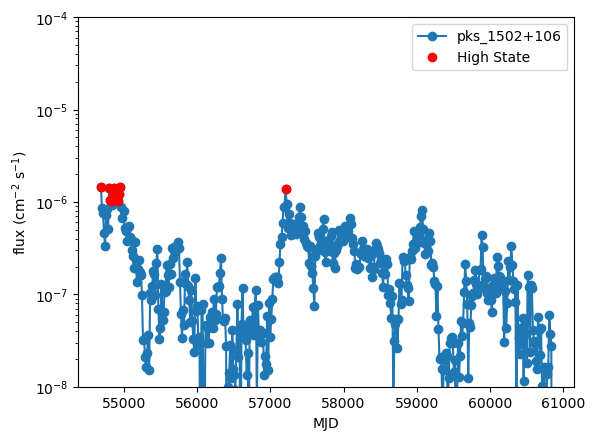

4fgl_j2202.7+4216:bl_lac 3
[58931.7 59085.7 59099.7 59113.7 59127.7 59211.7 59225.7 59239.7 59253.7
 59267.7 59281.7 59295.7 59309.7 59323.7 59337.7 59351.7 59393.7 59407.7
 59421.7 59435.7 59449.7 59477.7 59491.7 59631.7 59645.7 59659.7 59673.7
 59743.7 59841.7 59869.7 59883.7 59897.7 59911.7 59925.7 59939.7 59995.7
 60009.7 60569.7 60583.7 60597.7 60723.7]


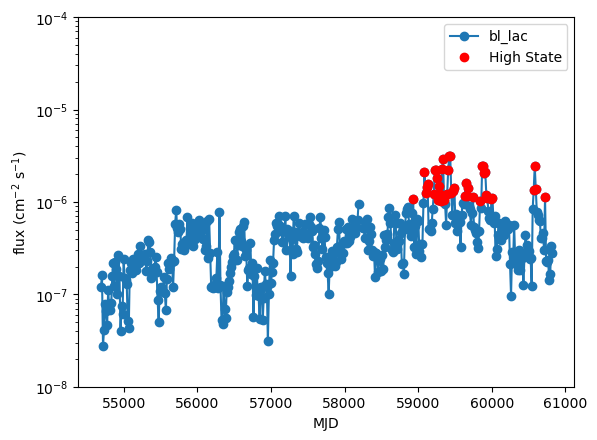

4fgl_j1104.4+3812:mkn_421 2
[]


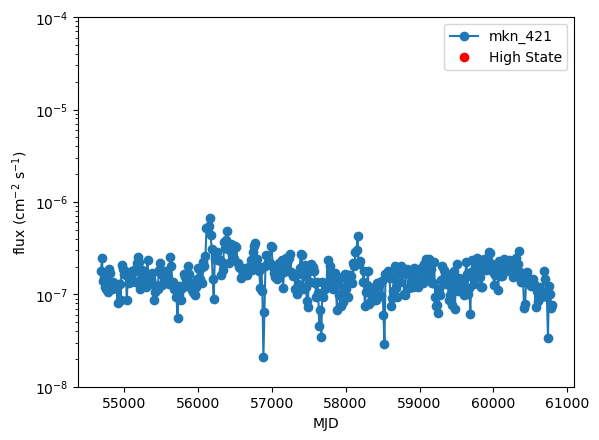

4fgl_j1224.9+2122:4c_+21.35 18
[55109.7 55179.7 55235.7 55305.7 55319.7 55333.7 55347.7 55361.7 55375.7
 55389.7 55445.7 55487.7 55529.7 55543.7 56537.7 56691.7 56705.7 56971.7]


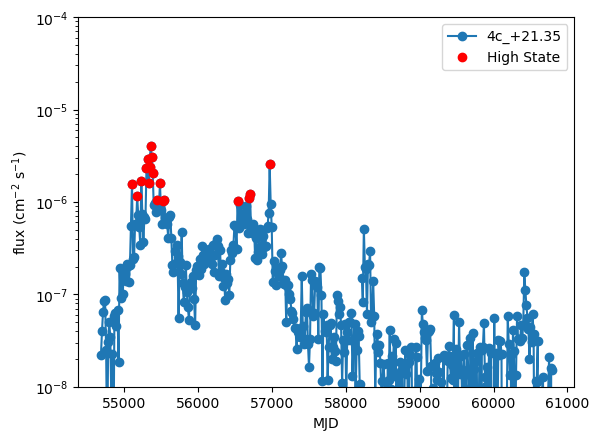

4fgl_j0112.1+2245:s2_0109+22 34
[]


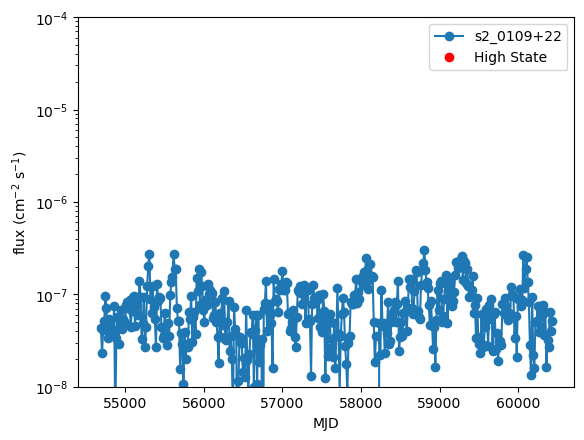

4fgl_j1256.1-0547:3c_279 5
[54787.7 54801.7 54815.7 54885.7 55039.7 56635.7 56649.7 56677.7 56719.7
 56747.7 56873.7 56985.7 57181.7 57195.7 57209.7 57825.7 57839.7 57853.7
 57881.7 57895.7 57923.7 57937.7 57951.7 58007.7 58021.7 58049.7 58119.7
 58133.7 58147.7 58161.7 58175.7 58189.7 58217.7 58231.7 58245.7 58259.7
 58273.7 58287.7 58301.7 58315.7 58329.7 58343.7 58455.7 58469.7 58581.7
 59001.7 59015.7 59449.7 59477.7 59491.7 59533.7]


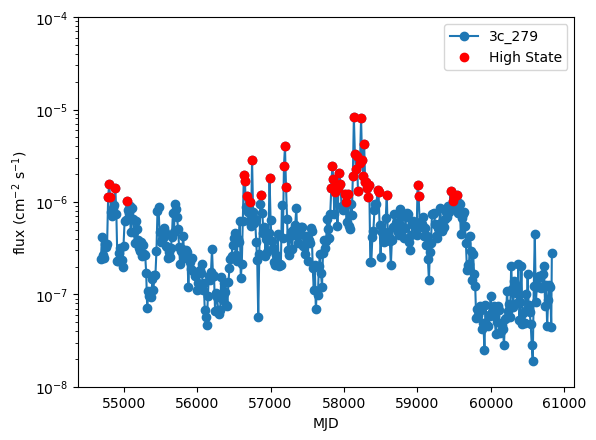

4fgl_j2158.8-3013:pks_2155-304 10
[]


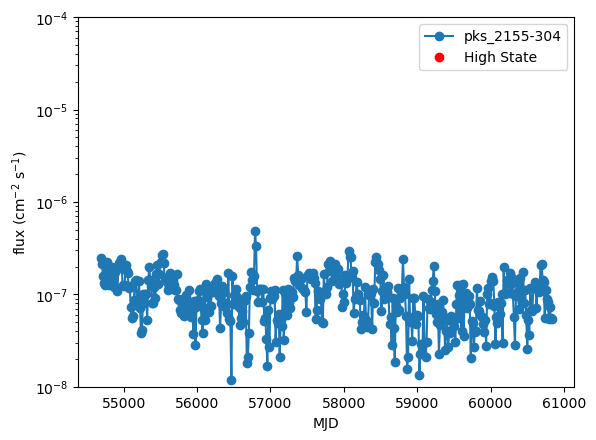

4fgl_j0538.8-4405:pks_0537-441 9
[]


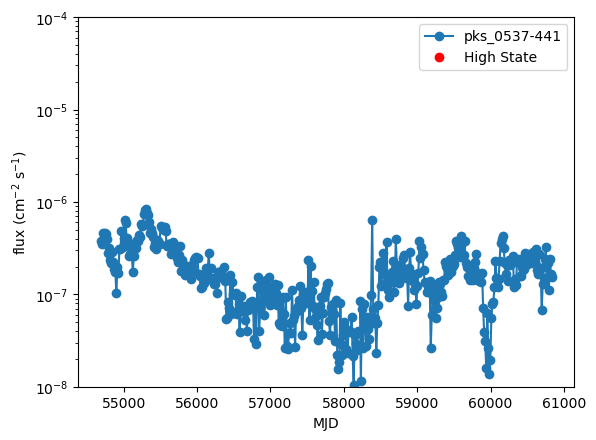

<Figure size 640x480 with 0 Axes>

In [132]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os

threshold_flux = 1.0e-6  # Define a threshold for flux
lc_file_dir = 'data_LC/14d'
file_list = get_lc_files(lc_file_dir) 

for file in file_list:
    if file.endswith('.fits'):
        lc_tab = Table.read(os.path.join(lc_file_dir, file))
        # Add a new column with the average of tmax_mjd and tmin_mjd
        lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd']) / 2., name='t_mjd', index=0)
        mask = (lc_tab['flux'] > threshold_flux) 
        # lc_tab.add_column((mask, name='high state', index=0)

        # fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
        sourcename_4fgl = file.split('_')[1] # Extract the 4FGL name from the filename
        sourceinfo = dict_sourcename[dict_sourcename['4FGL name'] == '4fgl_' + sourcename_4fgl]
        sourcename_assoc = sourceinfo['assoc name'].data[0]
        sourceindex = sourceinfo['index'].data[0]
        print('4fgl_' + sourcename_4fgl + ':' + str(sourcename_assoc) + ' ' + str(sourceindex))
        print(np.round(lc_tab['t_mjd'][mask],1))
        # print(sourcename_assoc)
        lc_x=lc_tab['t_mjd']
        lc_y=lc_tab['flux']
        plt.plot(lc_x,lc_y ,marker='o',label=sourcename_assoc)
        plt.plot(lc_x[mask], lc_y[mask], marker='o', linestyle='', color='red', label='High State')

        # lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
        # plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
        plt.xlabel('MJD')
        plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
        plt.yscale('log')
        plt.ylim(1e-8, 1e-4)
        plt.legend()
        plt.show()
        plt.tight_layout()

        

